# Demo for reproducing Lotfi 2025 fiber photometry analysis from NWB files.

This script reproduce the complete MATLAB analysis pipeline from RAW signals and compare reproduced results with pre-processed data already stored in NWB (from original .mat files)

Based on the MATLAB analysis scripts by Nick Hollon (Hnasko Lab).

**Core Processing Steps:**

1. Demodulated raw signal (330 Hz & 210 Hz carriers)
2. Downsampled to 100 Hz
3. Validated against NWB-stored signals (r > 0.9965)
4. Calculated dF/F using bi-exponential baseline correction
5. Extracted and normalized 15 trials

**Advanced Analysis:**

6. Computed summary statistics for 3 stimulus conditions
7. Generated stimulus-offset aligned traces
8. Calculated delta metrics (pre vs post comparisons)
9. Performed detailed time window analysis
10. Created export-ready data formats
11. Analyzed per-trial variability
12. Compared response dynamics across conditions

### Import required libraries

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as scipy_signal

# Analysis functions
from analysis_functions import (
    baseline_normalize_trials,
    calculate_dff_with_biexponential_fit,
    calculate_summary_statistics,
    extract_trials_around_events,
    get_standard_time_windows,
    organize_by_stimulus_condition,
)

# NWB and DANDI access
from stream_from_dandi import load_nwb_from_dandi

# Configure matplotlib
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["font.size"] = 10

## Load NWB File from DANDI

In [37]:
DANDISET_ID = "001528"
SUBJECT_ID = "C4561"  # Example subject (SNr GABA neuron recording)
SESSION_ID = "varying-durations"  # or "varying-frequencies"

print("=" * 100)
print("REPRODUCING LOTFI 2025 MATLAB FIBER PHOTOMETRY ANALYSIS IN PYTHON")
print("=" * 100)
print(f"\nLoading NWB file from DANDI Archive")
print(f"  Dandiset: {DANDISET_ID}")
print(f"  Subject: {SUBJECT_ID}")
print(f"  Session: {SESSION_ID}\n")

nwbfile, io = load_nwb_from_dandi(DANDISET_ID, SUBJECT_ID, SESSION_ID)

print(f"Session Information:")
print(f"  Start time: {nwbfile.session_start_time}")
print(f"  Subject: {nwbfile.subject.subject_id}")
print(f"  Genotype: {nwbfile.subject.genotype}")
print(f"  Description: {nwbfile.session_description}")

REPRODUCING LOTFI 2025 MATLAB FIBER PHOTOMETRY ANALYSIS IN PYTHON

Loading NWB file from DANDI Archive
  Dandiset: 001528
  Subject: C4561
  Session: varying-durations

Session Information:
  Start time: 2024-01-18 10:24:56-00:01
  Subject: C4561
  Genotype: VGlut2-cre x VGAT-flp
  Description: The subject is placed in a plastic tub and is recorded for 3.5 minutes. The subject receives a 40 Hz stimulation at various durations (i.e. 250ms, 1s and 4s) 5 times for each duration) with an inter-stimulus interval (ISI) of 10s. 


## Extract RAW Modulated Signal (Starting Point for Reproduction)

In [38]:
print("\n" + "=" * 100)
print("EXTRACT RAW MODULATED SIGNAL")
print("=" * 100)
print("\nThis is the starting point - the raw photodetector signal before any processing.")
print("We will reproduce ALL subsequent processing steps from this raw signal.\n")

# Get raw modulated signal from acquisition
raw_signal_name = None
for name in nwbfile.acquisition.keys():
    if "raw" in name.lower() and "signal" in name.lower():
        raw_signal_name = name
        break

if raw_signal_name is None:
    raise ValueError("Could not find raw modulated signal in NWB file")

raw_signal = nwbfile.acquisition[raw_signal_name].data[:]
raw_fs = float(nwbfile.acquisition[raw_signal_name].rate)

print(f"Raw modulated signal: {raw_signal_name}")
print(f"  Sampling rate: {raw_fs} Hz")
print(f"  Length: {len(raw_signal)} samples")
print(f"  Duration: {len(raw_signal) / raw_fs:.2f} seconds")
print(f"  Data range: [{raw_signal.min():.2f}, {raw_signal.max():.2f}]")


EXTRACT RAW MODULATED SIGNAL

This is the starting point - the raw photodetector signal before any processing.
We will reproduce ALL subsequent processing steps from this raw signal.

Raw modulated signal: raw_signal_SNr
  Sampling rate: 6103.515625 Hz
  Length: 1580544 samples
  Duration: 258.96 seconds
  Data range: [-0.02, 0.81]


## Reproduce Signal Demodulation (MATLAB Step 1)

In [39]:
print("\n" + "=" * 100)
print("REPRODUCE SIGNAL DEMODULATION")
print("=" * 100)
print("\nDemodulating raw signal to extract calcium (465nm) and isosbestic (405nm) components.")
print("This reproduces the MATLAB demodulation process:\n")
print("  Driver frequencies:")
print("    - Calcium (465nm): 330 Hz")
print("    - Isosbestic (405nm): 210 Hz")
print("  Filter: 2nd-order Butterworth lowpass, 6 Hz cutoff\n")

# Demodulation parameters (from MATLAB)
DRIVER_FREQ_CALCIUM = 330  # Hz
DRIVER_FREQ_ISOSBESTIC = 210  # Hz
LOWPASS_CUTOFF = 6  # Hz

# Create lowpass filter
b, a = scipy_signal.butter(2, LOWPASS_CUTOFF / (raw_fs / 2), "low")

# Time vector
t = np.arange(len(raw_signal)) / raw_fs

print("Demodulating calcium channel (330 Hz)...")
# Demodulate calcium (465nm) channel
sin_465 = raw_signal * np.sin(2 * np.pi * DRIVER_FREQ_CALCIUM * t)
cos_465 = raw_signal * np.cos(2 * np.pi * DRIVER_FREQ_CALCIUM * t)
sin_465_filt = scipy_signal.filtfilt(b, a, sin_465)
cos_465_filt = scipy_signal.filtfilt(b, a, cos_465)
calcium_demod_raw = np.sqrt(sin_465_filt**2 + cos_465_filt**2)

print("Demodulating isosbestic channel (210 Hz)...")
# Demodulate isosbestic (405nm) channel
sin_405 = raw_signal * np.sin(2 * np.pi * DRIVER_FREQ_ISOSBESTIC * t)
cos_405 = raw_signal * np.cos(2 * np.pi * DRIVER_FREQ_ISOSBESTIC * t)
sin_405_filt = scipy_signal.filtfilt(b, a, sin_405)
cos_405_filt = scipy_signal.filtfilt(b, a, cos_405)
isosbestic_demod_raw = np.sqrt(sin_405_filt**2 + cos_405_filt**2)

print(f"\nDemodulated signals:")
print(f"  Calcium: {len(calcium_demod_raw)} samples at {raw_fs} Hz")
print(f"  Isosbestic: {len(isosbestic_demod_raw)} samples at {raw_fs} Hz")


REPRODUCE SIGNAL DEMODULATION

Demodulating raw signal to extract calcium (465nm) and isosbestic (405nm) components.
This reproduces the MATLAB demodulation process:

  Driver frequencies:
    - Calcium (465nm): 330 Hz
    - Isosbestic (405nm): 210 Hz
  Filter: 2nd-order Butterworth lowpass, 6 Hz cutoff

Demodulating calcium channel (330 Hz)...
Demodulating isosbestic channel (210 Hz)...

Demodulated signals:
  Calcium: 1580544 samples at 6103.515625 Hz
  Isosbestic: 1580544 samples at 6103.515625 Hz


## Reproduce Downsampling (MATLAB Step 2)

In [40]:
print("\n" + "=" * 100)
print("REPRODUCE DOWNSAMPLING TO 100 Hz")
print("=" * 100)
print("\nDownsampling from {:.2f} Hz to 100 Hz using gridded interpolation.\n".format(raw_fs))

TARGET_FS = 100.0  # Hz

# Downsample using interpolation (matches MATLAB griddedInterpolant)
t_raw = np.arange(len(calcium_demod_raw)) / raw_fs
t_downsampled = np.arange(0, t_raw[-1], 1 / TARGET_FS)

calcium_reproduced = np.interp(t_downsampled, t_raw, calcium_demod_raw)
isosbestic_reproduced = np.interp(t_downsampled, t_raw, isosbestic_demod_raw)

print(f"Reproduced downsampled signals:")
print(f"  Calcium: {len(calcium_reproduced)} samples at {TARGET_FS} Hz")
print(f"  Isosbestic: {len(isosbestic_reproduced)} samples at {TARGET_FS} Hz")


REPRODUCE DOWNSAMPLING TO 100 Hz

Downsampling from 6103.52 Hz to 100 Hz using gridded interpolation.

Reproduced downsampled signals:
  Calcium: 25896 samples at 100.0 Hz
  Isosbestic: 25896 samples at 100.0 Hz


### Compare Reproduced Signals with NWB Stored Signals


VALIDATION 1: COMPARE REPRODUCED SIGNALS WITH NWB-STORED SIGNALS

Comparison Results:

Calcium Signal (465nm):
  Correlation: 0.998914
  RMSE: 0.0002
  Mean difference: -0.0000

Isosbestic Signal (405nm):
  Correlation: 0.996516
  RMSE: 0.0001
  Mean difference: -0.0000

⚠ WARNING: Correlation < 0.999. Check demodulation parameters.


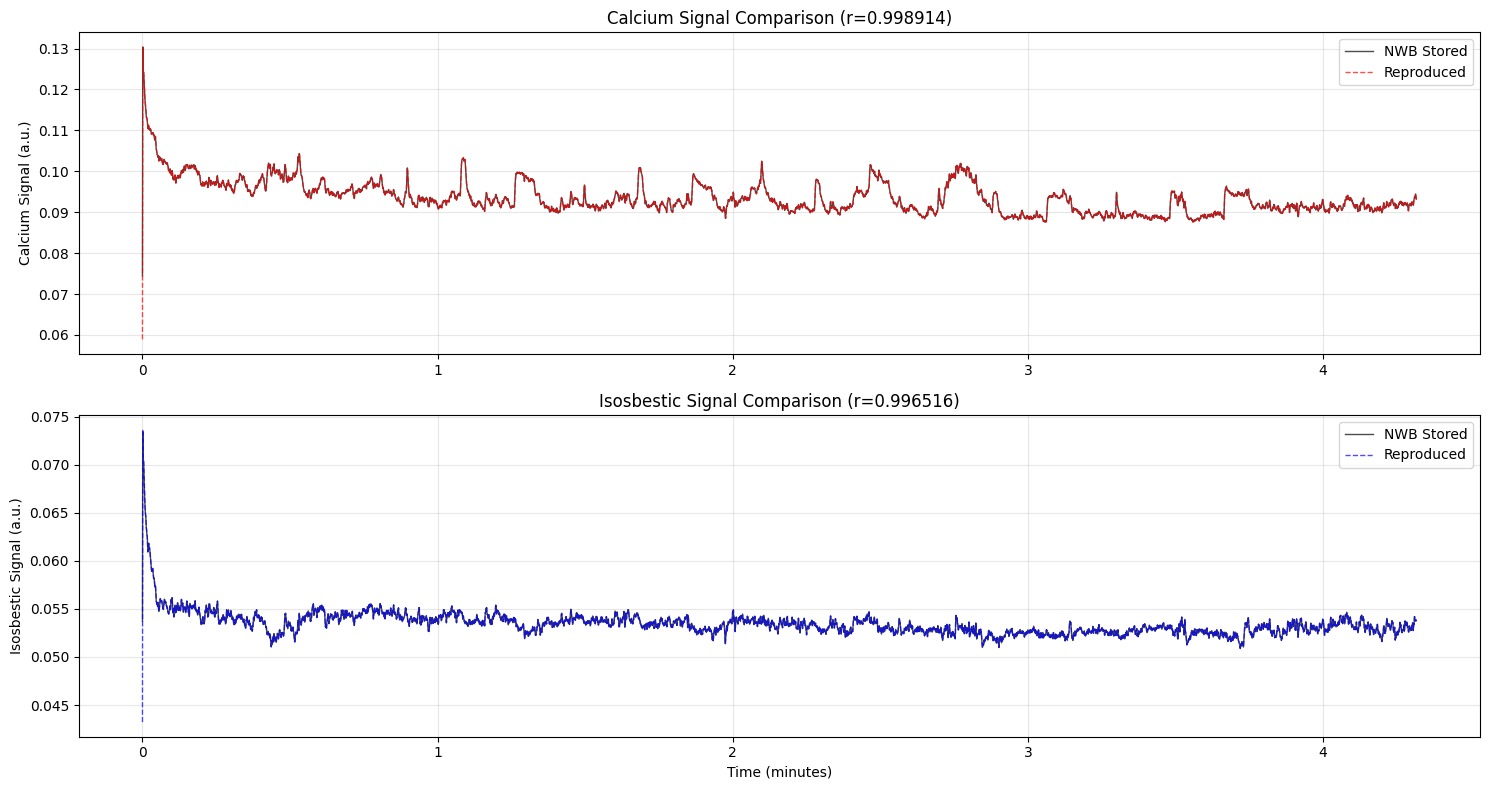

In [41]:
print("\n" + "=" * 100)
print("VALIDATION 1: COMPARE REPRODUCED SIGNALS WITH NWB-STORED SIGNALS")
print("=" * 100)

# Get the pre-processed signals from NWB
ophys_module = nwbfile.processing["ophys"]

# Find signal names
calcium_nwb_name = None
isosbestic_nwb_name = None
for name in ophys_module.data_interfaces.keys():
    if "downsampled_calcium" in name.lower():
        calcium_nwb_name = name
    elif "downsampled_isosbestic" in name.lower():
        isosbestic_nwb_name = name

calcium_nwb = ophys_module[calcium_nwb_name].data[:]
isosbestic_nwb = ophys_module[isosbestic_nwb_name].data[:]

# Handle potential length differences
min_len = min(len(calcium_reproduced), len(calcium_nwb))
calcium_reproduced = calcium_reproduced[:min_len]
isosbestic_reproduced = isosbestic_reproduced[:min_len]
calcium_nwb = calcium_nwb[:min_len]
isosbestic_nwb = isosbestic_nwb[:min_len]

# Calculate correlation and RMSE
corr_calcium = np.corrcoef(calcium_reproduced, calcium_nwb)[0, 1]
corr_isosbestic = np.corrcoef(isosbestic_reproduced, isosbestic_nwb)[0, 1]

rmse_calcium = np.sqrt(np.mean((calcium_reproduced - calcium_nwb) ** 2))
rmse_isosbestic = np.sqrt(np.mean((isosbestic_reproduced - isosbestic_nwb) ** 2))

print(f"\nComparison Results:")
print(f"\nCalcium Signal (465nm):")
print(f"  Correlation: {corr_calcium:.6f}")
print(f"  RMSE: {rmse_calcium:.4f}")
print(f"  Mean difference: {np.mean(calcium_reproduced - calcium_nwb):.4f}")

print(f"\nIsosbestic Signal (405nm):")
print(f"  Correlation: {corr_isosbestic:.6f}")
print(f"  RMSE: {rmse_isosbestic:.4f}")
print(f"  Mean difference: {np.mean(isosbestic_reproduced - isosbestic_nwb):.4f}")

if corr_calcium > 0.999 and corr_isosbestic > 0.999:
    print(f"\n✓ VALIDATION PASSED: Reproduced signals match NWB-stored signals (r > 0.999)")
else:
    print(f"\n⚠ WARNING: Correlation < 0.999. Check demodulation parameters.")

# Visualize comparison
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

time_min = t_downsampled[:min_len] / 60

# Plot calcium comparison
axes[0].plot(time_min, calcium_nwb, "k-", linewidth=1, alpha=0.7, label="NWB Stored")
axes[0].plot(time_min, calcium_reproduced, "r--", linewidth=1, alpha=0.7, label="Reproduced")
axes[0].set_ylabel("Calcium Signal (a.u.)")
axes[0].set_title(f"Calcium Signal Comparison (r={corr_calcium:.6f})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot isosbestic comparison
axes[1].plot(time_min, isosbestic_nwb, "k-", linewidth=1, alpha=0.7, label="NWB Stored")
axes[1].plot(time_min, isosbestic_reproduced, "b--", linewidth=1, alpha=0.7, label="Reproduced")
axes[1].set_xlabel("Time (minutes)")
axes[1].set_ylabel("Isosbestic Signal (a.u.)")
axes[1].set_title(f"Isosbestic Signal Comparison (r={corr_isosbestic:.6f})")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Calculate dF/F from Reproduced Signals

In [42]:
print("\n" + "=" * 100)
print("CALCULATE dF/F FROM REPRODUCED SIGNALS")
print("=" * 100)
print("\nCalculating dF/F using bi-exponential baseline correction.")
print("This matches the MATLAB two-step fitting process:\n")
print("  1. Bi-exponential fit to isosbestic (405nm) signal")
print("  2. Robust linear regression to scale to calcium (465nm) signal")
print("  3. Calculate dF/F = 100 * (Calcium - Baseline) / Baseline\n")

dff_reproduced, fit_results = calculate_dff_with_biexponential_fit(
    calcium_reproduced,
    isosbestic_reproduced,
    sampling_rate=TARGET_FS,
    exclude_first_seconds=1.0,
)

slope, intercept = fit_results["linear_coefficients"]

print(f"dF/F Calculation Complete:")
print(f"  Mean: {np.nanmean(dff_reproduced):.2f}%")
print(f"  Std: {np.nanstd(dff_reproduced):.2f}%")
print(f"  Range: [{np.nanmin(dff_reproduced):.2f}, {np.nanmax(dff_reproduced):.2f}]%")
print(f"\nBaseline fit parameters:")
print(f"  Slope: {slope:.4f}")
print(f"  Intercept: {intercept:.4f}")


CALCULATE dF/F FROM REPRODUCED SIGNALS

Calculating dF/F using bi-exponential baseline correction.
This matches the MATLAB two-step fitting process:

  1. Bi-exponential fit to isosbestic (405nm) signal
  2. Robust linear regression to scale to calcium (465nm) signal
  3. Calculate dF/F = 100 * (Calcium - Baseline) / Baseline



dF/F Calculation Complete:
  Mean: 0.07%
  Std: 3.36%
  Range: [-40.09, 32.44]%

Baseline fit parameters:
  Slope: 3.3775
  Intercept: -0.0869


c:\Users\amtra\CatalystNeuro\hnasko-lab-to-nwb\src\hnasko_lab_to_nwb\lotfi_2025\reproduced_analysis\analysis_functions.py:132: RuntimeWarning: Statsmodels not available. Using standard linear regression.
  warnings.warn(


### Validate Reproduced dF/F against NWB-Stored dF/F


VALIDATION 2: COMPARE REPRODUCED dF/F WITH NWB-STORED dF/F

dF/F Signal Comparison:
  NWB signal: deltaF_over_F_SNr
  Length: 25895 samples
  Correlation: 0.998373
  RMSE: 0.5692%
  Mean difference: -0.5358%
  Max absolute difference: 16.1628%

✓ VALIDATION PASSED: Reproduced dF/F matches NWB-stored dF/F (r > 0.99)


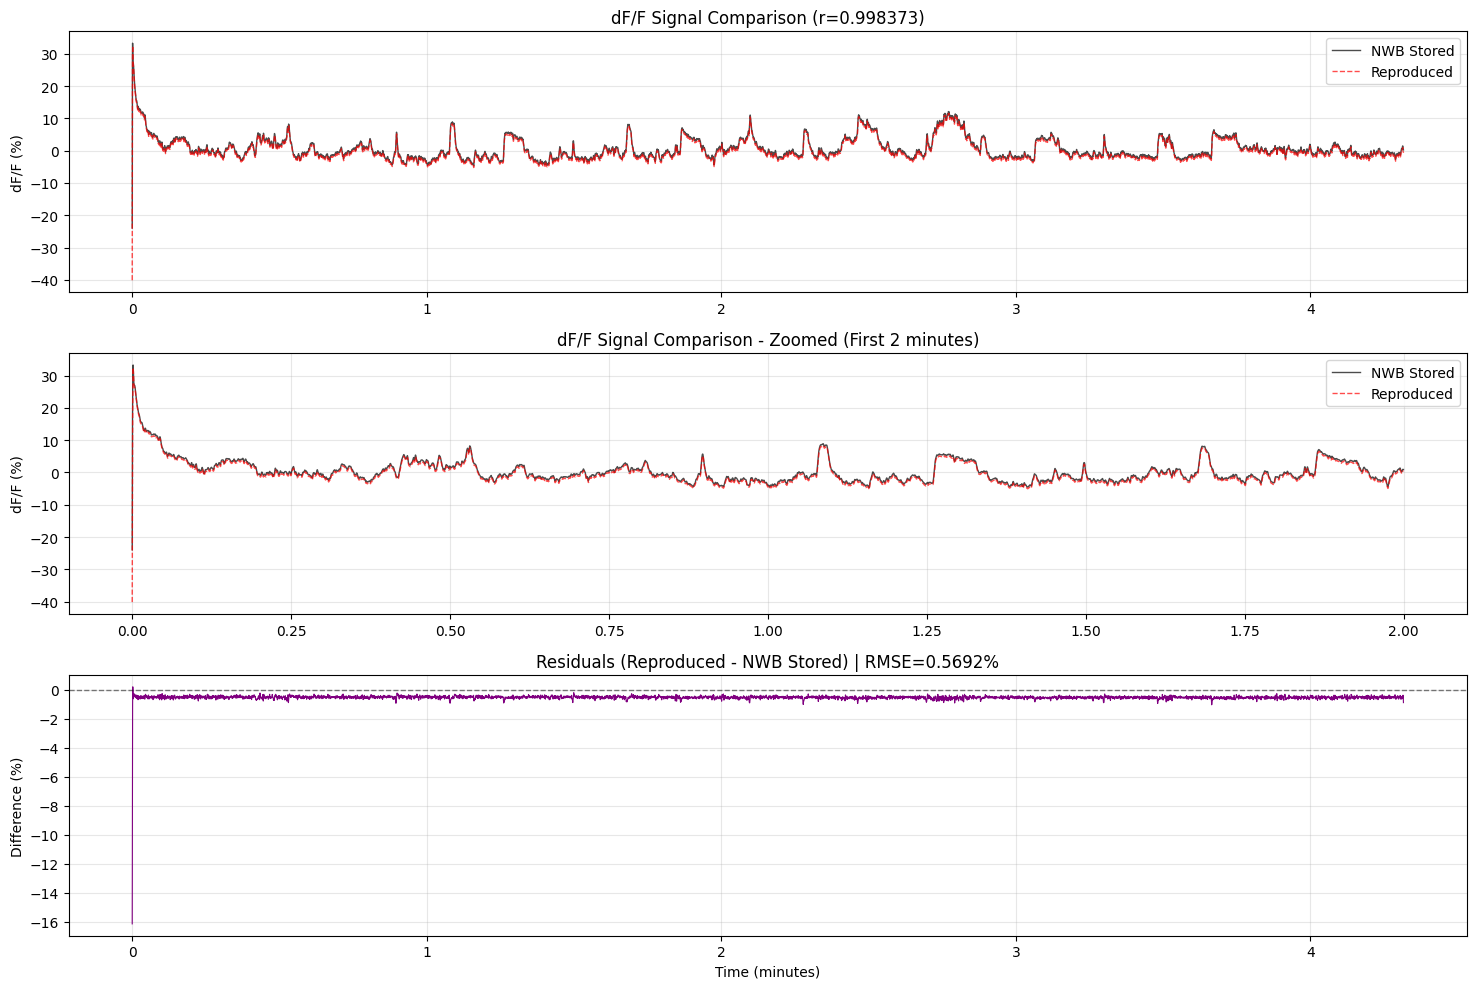


dF/F validation plots displayed.


In [43]:
print("\n" + "=" * 100)
print("VALIDATION 2: COMPARE REPRODUCED dF/F WITH NWB-STORED dF/F")
print("=" * 100)

# Find dF/F signal in NWB
dff_nwb_name = None
for name in ophys_module.data_interfaces.keys():
    if "deltaf_over_f" in name.lower() or "dff" in name.lower():
        dff_nwb_name = name
        break

if dff_nwb_name is None:
    print("\n⚠ WARNING: Could not find dF/F signal in NWB file for validation.")
    print("Skipping dF/F validation step.")
else:
    dff_nwb = ophys_module[dff_nwb_name].data[:]

    # Handle potential length differences
    min_len_dff = min(len(dff_reproduced), len(dff_nwb))
    dff_reproduced_trim = dff_reproduced[:min_len_dff]
    dff_nwb_trim = dff_nwb[:min_len_dff]

    # Calculate correlation and RMSE
    corr_dff = np.corrcoef(dff_reproduced_trim, dff_nwb_trim)[0, 1]
    rmse_dff = np.sqrt(np.mean((dff_reproduced_trim - dff_nwb_trim) ** 2))
    mean_diff_dff = np.mean(dff_reproduced_trim - dff_nwb_trim)

    print(f"\ndF/F Signal Comparison:")
    print(f"  NWB signal: {dff_nwb_name}")
    print(f"  Length: {len(dff_nwb)} samples")
    print(f"  Correlation: {corr_dff:.6f}")
    print(f"  RMSE: {rmse_dff:.4f}%")
    print(f"  Mean difference: {mean_diff_dff:.4f}%")
    print(f"  Max absolute difference: {np.max(np.abs(dff_reproduced_trim - dff_nwb_trim)):.4f}%")

    if corr_dff > 0.99:
        print(f"\n✓ VALIDATION PASSED: Reproduced dF/F matches NWB-stored dF/F (r > 0.99)")
    else:
        print(f"\n⚠ WARNING: Correlation < 0.99. Some differences detected in dF/F calculation.")

    # Visualize dF/F comparison
    fig, axes = plt.subplots(3, 1, figsize=(15, 10))

    time_min_dff = t_downsampled[:min_len_dff] / 60

    # Plot 1: Full trace comparison
    axes[0].plot(time_min_dff, dff_nwb_trim, "k-", linewidth=1, alpha=0.7, label="NWB Stored")
    axes[0].plot(time_min_dff, dff_reproduced_trim, "r--", linewidth=1, alpha=0.7, label="Reproduced")
    axes[0].set_ylabel("dF/F (%)")
    axes[0].set_title(f"dF/F Signal Comparison (r={corr_dff:.6f})")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Zoomed view (first 2 minutes)
    zoom_samples = min(int(2 * 60 * TARGET_FS), min_len_dff)
    axes[1].plot(
        time_min_dff[:zoom_samples], dff_nwb_trim[:zoom_samples], "k-", linewidth=1, alpha=0.7, label="NWB Stored"
    )
    axes[1].plot(
        time_min_dff[:zoom_samples],
        dff_reproduced_trim[:zoom_samples],
        "r--",
        linewidth=1,
        alpha=0.7,
        label="Reproduced",
    )
    axes[1].set_ylabel("dF/F (%)")
    axes[1].set_title("dF/F Signal Comparison - Zoomed (First 2 minutes)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Plot 3: Difference (residuals)
    axes[2].plot(time_min_dff, dff_reproduced_trim - dff_nwb_trim, "purple", linewidth=0.8)
    axes[2].axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    axes[2].set_xlabel("Time (minutes)")
    axes[2].set_ylabel("Difference (%)")
    axes[2].set_title(f"Residuals (Reproduced - NWB Stored) | RMSE={rmse_dff:.4f}%")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\ndF/F validation plots displayed.")

## Extract and Analyze Trials

In [44]:
print("\n" + "=" * 100)
print("EXTRACT AND ANALYZE TRIALS")
print("=" * 100)

# Organize trials by stimulus condition
organized_data = organize_by_stimulus_condition(
    nwbfile,
    dff_reproduced,
    sampling_rate=TARGET_FS,
)

print(f"\nStimulus conditions found:")
for condition_label, data_dict in organized_data.items():
    n_trials = data_dict["trials"].shape[0]
    duration = data_dict["duration"]
    print(f"  {condition_label}: {n_trials} trials (duration={duration}s)")


EXTRACT AND ANALYZE TRIALS

Stimulus conditions found:
  Stim250ms: 5 trials (duration=0.25s)
  Stim1s: 5 trials (duration=1.0s)
  Stim4s: 5 trials (duration=4.0s)


## Calculate and Display Summary Statistics

In [45]:
print("\n" + "=" * 100)
print("CALCULATE SUMMARY STATISTICS")
print("=" * 100)

statistics_by_condition = {}

for condition_label, data_dict in organized_data.items():
    normalized_trials = data_dict["normalized"]
    time_vec = data_dict["time_vector"]
    stim_duration = data_dict["duration"]

    # Get standard time windows
    time_windows = get_standard_time_windows(stim_duration)

    # Calculate statistics
    stats = calculate_summary_statistics(
        normalized_trials,
        time_vec,
        time_windows,
        sampling_rate=TARGET_FS,
    )

    statistics_by_condition[condition_label] = {
        "windows": time_windows,
        "statistics": stats,
    }

    print(f"\n{condition_label} (n={normalized_trials.shape[0]} trials):")
    print(f"  During stimulus:")
    during_idx = list(time_windows.keys()).index("during_stim")
    print(f"    Mean dF/F: {stats['mean'][during_idx]:.2f}%")
    print(f"    Peak: {stats['peak'][during_idx]:.2f}%")
    print(f"    AUC: {stats['auc'][during_idx]:.2f}")


CALCULATE SUMMARY STATISTICS

Stim250ms (n=5 trials):
  During stimulus:
    Mean dF/F: 3.84%
    Peak: 6.63%
    AUC: 0.92

Stim1s (n=5 trials):
  During stimulus:
    Mean dF/F: 6.35%
    Peak: 7.74%
    AUC: 6.31

Stim4s (n=5 trials):
  During stimulus:
    Mean dF/F: 5.68%
    Peak: 7.26%
    AUC: 22.70



VISUALIZE TRIAL-ALIGNED RESPONSES


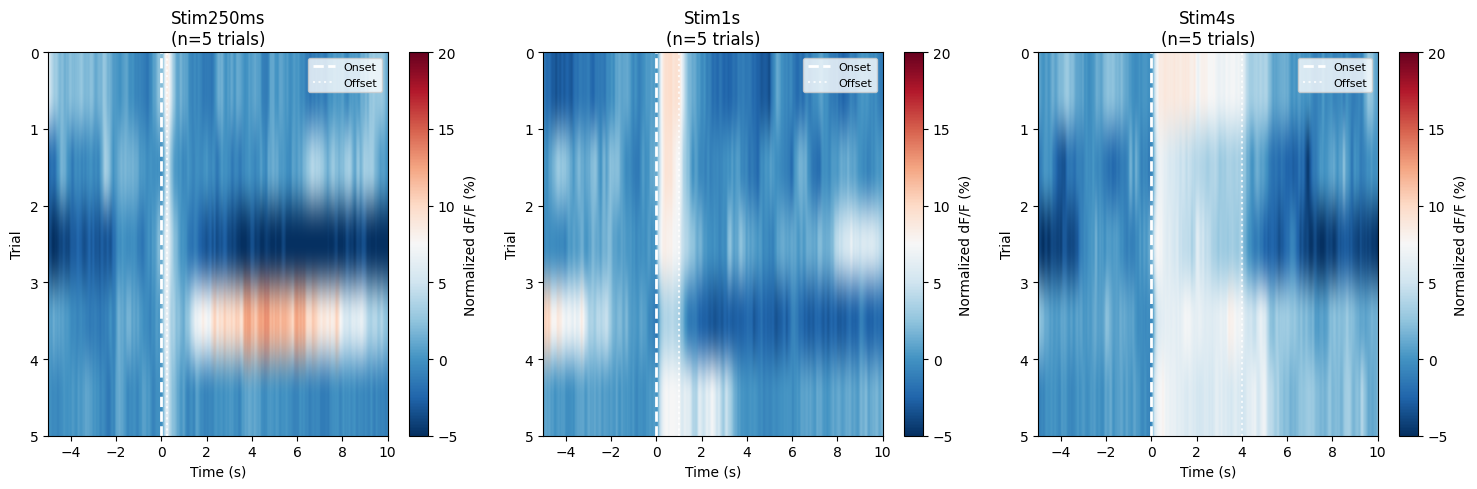

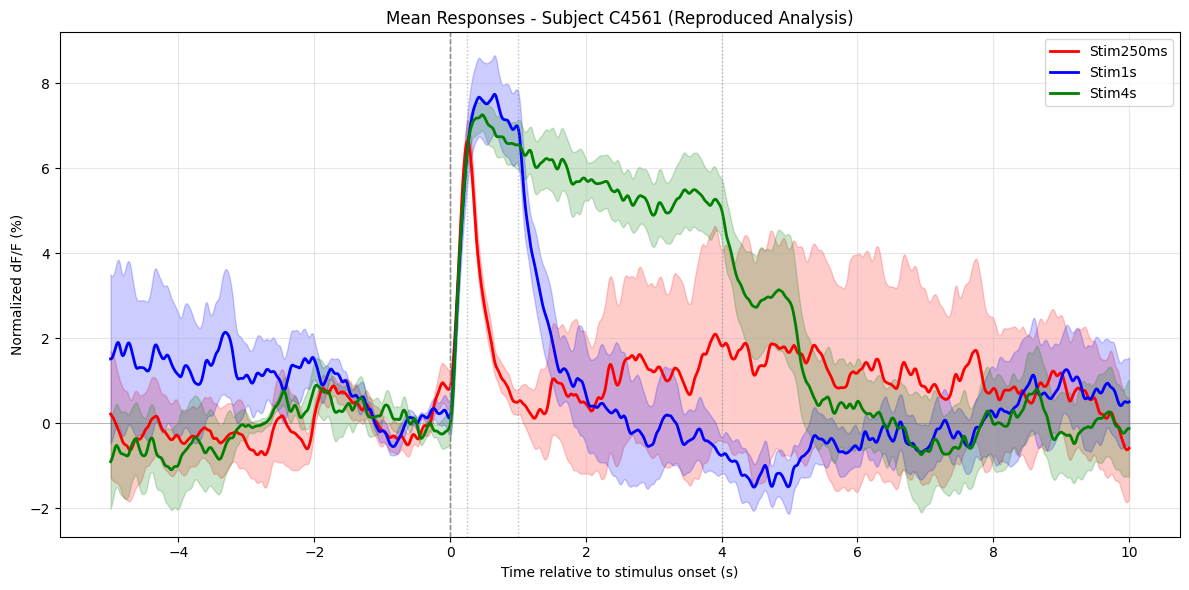

In [46]:
print("\n" + "=" * 100)
print("VISUALIZE TRIAL-ALIGNED RESPONSES")
print("=" * 100)

# Create heatmaps
n_conditions = len(organized_data)
fig, axes = plt.subplots(1, n_conditions, figsize=(5 * n_conditions, 5))

if n_conditions == 1:
    axes = [axes]

for idx, (condition_label, data_dict) in enumerate(organized_data.items()):
    normalized_trials = data_dict["normalized"]
    time_vec = data_dict["time_vector"]
    n_trials = normalized_trials.shape[0]

    im = axes[idx].imshow(
        normalized_trials,
        aspect="auto",
        cmap="RdBu_r",
        vmin=-5,
        vmax=20,
        extent=[time_vec[0], time_vec[-1], n_trials, 0],
    )

    axes[idx].axvline(0, color="white", linestyle="--", linewidth=2, label="Onset")
    axes[idx].axvline(data_dict["duration"], color="white", linestyle=":", linewidth=1.5, alpha=0.8, label="Offset")
    axes[idx].set_xlabel("Time (s)")
    axes[idx].set_ylabel("Trial")
    axes[idx].set_title(f"{condition_label}\n(n={n_trials} trials)")
    axes[idx].legend(loc="upper right", fontsize=8)
    plt.colorbar(im, ax=axes[idx], label="Normalized dF/F (%)")

plt.tight_layout()
plt.show()

# Plot mean traces
fig, ax = plt.subplots(figsize=(12, 6))
colors = {"Stim250ms": "red", "Stim1s": "blue", "Stim4s": "green"}

for condition_label, data_dict in organized_data.items():
    normalized_trials = data_dict["normalized"]
    time_vec = data_dict["time_vector"]

    mean_trace = np.nanmean(normalized_trials, axis=0)
    sem_trace = np.nanstd(normalized_trials, axis=0) / np.sqrt(normalized_trials.shape[0])

    color = colors.get(condition_label, "black")
    ax.plot(time_vec, mean_trace, color=color, linewidth=2, label=condition_label)
    ax.fill_between(time_vec, mean_trace - sem_trace, mean_trace + sem_trace, color=color, alpha=0.2)
    ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.5)
    ax.axvline(data_dict["duration"], color="gray", linestyle=":", linewidth=1, alpha=0.5)

ax.axhline(0, color="black", linestyle="-", linewidth=0.5, alpha=0.3)
ax.set_xlabel("Time relative to stimulus onset (s)")
ax.set_ylabel("Normalized dF/F (%)")
ax.set_title(f"Mean Responses - Subject {SUBJECT_ID} (Reproduced Analysis)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Calculate Stimulus-Offset Aligned Traces


In [ ]:
print("\n" + "=" * 100)
print("STIMULUS-OFFSET ALIGNED ANALYSIS")
print("=" * 100)
print("\nRe-aligning traces to stimulus OFFSET for rebound analysis.")
print("This captures post-stimulus dynamics more clearly.\n")

# Create offset-aligned traces for each condition
offset_aligned_data = {}

for condition_label, data_dict in organized_data.items():
    normalized_trials = data_dict["normalized"]
    time_vec = data_dict["time_vector"]
    stim_duration = data_dict["duration"]

    # Create new matrix aligned to stimulus offset
    # Keep 5s before onset, align to offset, keep 10s after
    total_duration = 5 + stim_duration + 10  # seconds
    n_samples = int(total_duration * TARGET_FS) + 1
    offset_aligned = np.full((normalized_trials.shape[0], n_samples), np.nan)

    # Calculate shift needed
    onset_idx = int(5 * TARGET_FS)  # Where onset is in original
    offset_idx_original = onset_idx + int(stim_duration * TARGET_FS)
    offset_idx_new = int((5 + stim_duration) * TARGET_FS)

    # Copy data with proper alignment
    valid_length = min(normalized_trials.shape[1], n_samples)
    offset_aligned[:, :valid_length] = normalized_trials[:, :valid_length]

    # Create time vector relative to offset
    time_vec_offset = np.arange(-5 - stim_duration, 10 + 1 / TARGET_FS, 1 / TARGET_FS)[:n_samples]

    offset_aligned_data[condition_label] = {
        "offset_aligned": offset_aligned,
        "time_vector_offset": time_vec_offset,
        "duration": stim_duration,
    }

    print(f"{condition_label}: Created offset-aligned traces")
    print(f"  Shape: {offset_aligned.shape}")
    print(f"  Time range: [{time_vec_offset[0]:.2f}, {time_vec_offset[-1]:.2f}] s relative to offset")


STEP 8: STIMULUS-OFFSET ALIGNED ANALYSIS

Re-aligning traces to stimulus OFFSET for rebound analysis.
This captures post-stimulus dynamics more clearly.

Stim250ms: Created offset-aligned traces
  Shape: (5, 1526)
  Time range: [-5.25, 10.00] s relative to offset
Stim1s: Created offset-aligned traces
  Shape: (5, 1601)
  Time range: [-6.00, 10.00] s relative to offset
Stim4s: Created offset-aligned traces
  Shape: (5, 1901)
  Time range: [-9.00, 10.00] s relative to offset


## Calculate Delta Metrics (Pre vs Post Comparisons)

In [60]:
print("\n" + "=" * 100)
print("CALCULATE DELTA METRICS")
print("=" * 100)
print("\nComputing delta metrics comparing different time periods.")
print("These capture changes from baseline to stimulus response.\n")

delta_metrics = {}

for condition_label, data_dict in organized_data.items():
    normalized_trials = data_dict["normalized"]
    time_vec = data_dict["time_vector"]
    stim_duration = data_dict["duration"]

    # Define time windows based on stimulus duration
    if stim_duration == 0.25:
        # For 250ms stim
        pre_stim_on = (-0.25, 0.0)  # 250ms before onset
        during_stim = (0.0, 0.25)  # During 250ms stim
        post_stim_off = (0.25, 1.25)  # 0-1s after offset

    elif stim_duration == 1.0:
        # For 1s stim
        pre_stim_on = (-0.25, 0.0)  # 250ms before onset
        during_stim = (0.0, 1.0)  # During 1s stim
        late_stim = (0.75, 1.0)  # Last 250ms of stim
        post_stim_off = (1.0, 2.0)  # 0-1s after offset

    elif stim_duration == 4.0:
        # For 4s stim
        pre_stim_on = (-0.25, 0.0)  # 250ms before onset
        during_stim = (0.0, 4.0)  # During 4s stim
        late_stim = (3.75, 4.0)  # Last 250ms of stim
        post_stim_off = (4.0, 5.0)  # 0-1s after offset

    # Extract mean dF/F for each window
    def get_window_mean(time_vec, trials, window):
        mask = (time_vec >= window[0]) & (time_vec <= window[1])
        return np.nanmean(trials[:, mask])

    pre_on_mean = get_window_mean(time_vec, normalized_trials, pre_stim_on)
    during_mean = get_window_mean(time_vec, normalized_trials, during_stim[:2])  # First part
    post_off_mean = get_window_mean(time_vec, normalized_trials, post_stim_off)

    # Calculate deltas
    delta_on_vs_during = during_mean - pre_on_mean
    delta_on_vs_post = post_off_mean - pre_on_mean

    if stim_duration >= 1.0:
        late_mean = get_window_mean(time_vec, normalized_trials, late_stim)
        delta_late_vs_post = post_off_mean - late_mean
    else:
        late_mean = during_mean
        delta_late_vs_post = post_off_mean - during_mean

    delta_metrics[condition_label] = {
        "pre_stim_onset_mean": pre_on_mean,
        "during_stim_mean": during_mean,
        "late_stim_mean": late_mean,
        "post_stim_offset_mean": post_off_mean,
        "delta_onset_vs_during": delta_on_vs_during,
        "delta_onset_vs_post_offset": delta_on_vs_post,
        "delta_late_vs_post_offset": delta_late_vs_post,
    }

    print(f"\n{condition_label} Delta Metrics:")
    print(f"  Pre-stim onset: {pre_on_mean:.2f}%")
    print(f"  During stim: {during_mean:.2f}%")
    print(f"  Late stim: {late_mean:.2f}%")
    print(f"  Post-stim offset: {post_off_mean:.2f}%")
    print(f"  Δ (During - Pre-onset): {delta_on_vs_during:.2f}%")
    print(f"  Δ (Post - Pre-onset): {delta_on_vs_post:.2f}%")
    print(f"  Δ (Post - Late stim): {delta_late_vs_post:.2f}%")


CALCULATE DELTA METRICS

Computing delta metrics comparing different time periods.
These capture changes from baseline to stimulus response.


Stim250ms Delta Metrics:
  Pre-stim onset: 0.77%
  During stim: 3.84%
  Late stim: 3.84%
  Post-stim offset: 1.88%
  Δ (During - Pre-onset): 3.07%
  Δ (Post - Pre-onset): 1.11%
  Δ (Post - Late stim): -1.96%

Stim1s Delta Metrics:
  Pre-stim onset: 0.25%
  During stim: 6.35%
  Late stim: 7.05%
  Post-stim offset: 2.52%
  Δ (During - Pre-onset): 6.10%
  Δ (Post - Pre-onset): 2.27%
  Δ (Post - Late stim): -4.53%

Stim4s Delta Metrics:
  Pre-stim onset: -0.20%
  During stim: 5.68%
  Late stim: 5.18%
  Post-stim offset: 3.24%
  Δ (During - Pre-onset): 5.88%
  Δ (Post - Pre-onset): 3.44%
  Δ (Post - Late stim): -1.94%


## Detailed Time Window Analysis

In [ ]:
print("\n" + "=" * 100)
print("DETAILED TIME WINDOW ANALYSIS")
print("=" * 100)
print("\nAnalyzing all standard time windows for comprehensive comparison.\n")

# Collect all metrics in an organized structure
all_window_metrics = {}

for condition_label, data_dict in organized_data.items():
    normalized_trials = data_dict["normalized"]
    time_vec = data_dict["time_vector"]
    stim_duration = data_dict["duration"]

    # Get all standard time windows
    time_windows = get_standard_time_windows(stim_duration)

    # Calculate metrics for all windows
    all_metrics = {}
    for window_name, (t_start, t_end) in time_windows.items():
        mask = (time_vec >= t_start) & (time_vec <= t_end)
        window_data = normalized_trials[:, mask]

        all_metrics[window_name] = {
            "mean": np.nanmean(window_data),
            "std": np.nanstd(window_data),
            "sem": np.nanstd(window_data) / np.sqrt(np.sum(~np.isnan(window_data))),
            "median": np.nanmedian(window_data),
            "min": np.nanmin(window_data),
            "max": np.nanmax(window_data),
        }

    all_window_metrics[condition_label] = all_metrics

    # Display summary
    print(f"\n{condition_label} - Detailed Window Metrics:")
    for window_name in list(time_windows.keys())[:5]:  # Show first 5
        metrics = all_metrics[window_name]
        print(f"  {window_name}:")
        print(f"    Mean ± SEM: {metrics['mean']:.2f} ± {metrics['sem']:.2f}%")
        print(f"    Range: [{metrics['min']:.2f}, {metrics['max']:.2f}]%")


STEP 10: DETAILED TIME WINDOW ANALYSIS

Analyzing all standard time windows for comprehensive comparison.


Stim250ms - Detailed Window Metrics:
  baseline_1s:
    Mean ± SEM: 0.00 ± 0.04%
    Range: [-1.64, 2.39]%
  baseline_4s:
    Mean ± SEM: -0.04 ± 0.03%
    Range: [-3.55, 3.37]%
  pre_stim_250ms:
    Mean ± SEM: 0.77 ± 0.08%
    Range: [-0.47, 2.39]%
  during_stim:
    Mean ± SEM: 3.84 ± 0.20%
    Range: [-0.16, 8.34]%
  post_stim_250ms:
    Mean ± SEM: 4.69 ± 0.15%
    Range: [1.55, 8.44]%

Stim1s - Detailed Window Metrics:
  baseline_1s:
    Mean ± SEM: 0.00 ± 0.03%
    Range: [-1.53, 1.34]%
  baseline_4s:
    Mean ± SEM: 0.83 ± 0.04%
    Range: [-3.16, 8.52]%
  pre_stim_250ms:
    Mean ± SEM: 0.25 ± 0.06%
    Range: [-1.53, 1.34]%
  during_stim:
    Mean ± SEM: 6.35 ± 0.12%
    Range: [-1.49, 9.85]%
  late_stim_250ms:
    Mean ± SEM: 7.05 ± 0.17%
    Range: [3.44, 9.46]%

Stim4s - Detailed Window Metrics:
  baseline_1s:
    Mean ± SEM: 0.00 ± 0.03%
    Range: [-1.33, 1.61]%
 

## Export-Ready Data Formatting

In [ ]:
print("\n" + "=" * 100)
print("EXPORT-READY DATA FORMATTING")
print("=" * 100)
print("\nFormatting data for export to GraphPad Prism or similar tools.\n")

# Create concatenated arrays for easy export
export_data = {}

# Concatenate mean traces across all conditions
for condition_label, data_dict in organized_data.items():
    normalized_trials = data_dict["normalized"]
    time_vec = data_dict["time_vector"]

    # Mean trace for each subject (in this case, single subject)
    mean_trace = np.nanmean(normalized_trials, axis=0)
    sem_trace = np.nanstd(normalized_trials, axis=0) / np.sqrt(normalized_trials.shape[0])

    export_data[f"{condition_label}_time"] = time_vec
    export_data[f"{condition_label}_mean"] = mean_trace
    export_data[f"{condition_label}_sem"] = sem_trace
    export_data[f"{condition_label}_individual_trials"] = normalized_trials

print("Export-ready arrays created:")
print(f"  Total arrays: {len(export_data)}")
print(f"  Available formats: time vectors, mean traces, SEM, individual trials")

# Create summary table
summary_table = []
for condition_label in organized_data.keys():
    metrics = statistics_by_condition[condition_label]["statistics"]
    windows = statistics_by_condition[condition_label]["windows"]

    during_idx = list(windows.keys()).index("during_stim")

    summary_table.append(
        {
            "Condition": condition_label,
            "Duration (s)": organized_data[condition_label]["duration"],
            "N Trials": organized_data[condition_label]["trials"].shape[0],
            "Mean During Stim (%)": metrics["mean"][during_idx],
            "Peak (%)": metrics["peak"][during_idx],
            "AUC": metrics["auc"][during_idx],
        }
    )

print("\nSummary Table:")
print("-" * 80)
for row in summary_table:
    print(
        f"{row['Condition']:12s} | Dur: {row['Duration (s)']:.2f}s | "
        f"N={row['N Trials']:2d} | Mean: {row['Mean During Stim (%)']:6.2f}% | "
        f"Peak: {row['Peak (%)']:6.2f}% | AUC: {row['AUC']:7.2f}"
    )


STEP 11: EXPORT-READY DATA FORMATTING

Formatting data for export to GraphPad Prism or similar tools.

Export-ready arrays created:
  Total arrays: 12
  Available formats: time vectors, mean traces, SEM, individual trials

Summary Table:
--------------------------------------------------------------------------------
Stim250ms    | Dur: 0.25s | N= 5 | Mean:   3.84% | Peak:   6.63% | AUC:    0.92
Stim1s       | Dur: 1.00s | N= 5 | Mean:   6.35% | Peak:   7.74% | AUC:    6.31
Stim4s       | Dur: 4.00s | N= 5 | Mean:   5.68% | Peak:   7.26% | AUC:   22.70


## Per-Trial Statistics and Variability

In [59]:
print("\n" + "=" * 100)
print("PER-TRIAL STATISTICS AND VARIABILITY")
print("=" * 100)
print("\nAnalyzing trial-to-trial variability.\n")

trial_variability = {}

for condition_label, data_dict in organized_data.items():
    normalized_trials = data_dict["normalized"]
    time_vec = data_dict["time_vector"]
    stim_duration = data_dict["duration"]

    # Get during-stim window
    during_mask = (time_vec >= 0) & (time_vec <= stim_duration)
    during_window = normalized_trials[:, during_mask]

    # Calculate per-trial metrics
    trial_means = np.nanmean(during_window, axis=1)
    trial_peaks = np.nanmax(during_window, axis=1)
    trial_aucs = np.array([np.trapz(during_window[i, :], dx=1 / TARGET_FS) for i in range(during_window.shape[0])])

    # Calculate variability measures
    trial_variability[condition_label] = {
        "mean_across_trials": {
            "mean": np.mean(trial_means),
            "std": np.std(trial_means),
            "cv": np.std(trial_means) / np.mean(trial_means) if np.mean(trial_means) != 0 else np.nan,
        },
        "peak_across_trials": {
            "mean": np.mean(trial_peaks),
            "std": np.std(trial_peaks),
            "cv": np.std(trial_peaks) / np.mean(trial_peaks) if np.mean(trial_peaks) != 0 else np.nan,
        },
        "auc_across_trials": {
            "mean": np.mean(trial_aucs),
            "std": np.std(trial_aucs),
            "cv": np.std(trial_aucs) / np.mean(trial_aucs) if np.mean(trial_aucs) != 0 else np.nan,
        },
    }

    print(f"{condition_label}:")
    print(
        f"  Mean dF/F per trial: {np.mean(trial_means):.2f} ± {np.std(trial_means):.2f}% (CV={trial_variability[condition_label]['mean_across_trials']['cv']:.2f})"
    )
    print(f"  Peak per trial: {np.mean(trial_peaks):.2f} ± {np.std(trial_peaks):.2f}%")
    print(f"  AUC per trial: {np.mean(trial_aucs):.2f} ± {np.std(trial_aucs):.2f}")


PER-TRIAL STATISTICS AND VARIABILITY

Analyzing trial-to-trial variability.

Stim250ms:
  Mean dF/F per trial: 3.84 ± 0.94% (CV=0.25)
  Peak per trial: 6.63 ± 1.06%
  AUC per trial: 0.92 ± 0.23
Stim1s:
  Mean dF/F per trial: 6.35 ± 1.75% (CV=0.28)
  Peak per trial: 7.83 ± 2.00%
  AUC per trial: 6.31 ± 1.73
Stim4s:
  Mean dF/F per trial: 5.68 ± 1.25% (CV=0.22)
  Peak per trial: 7.93 ± 0.70%
  AUC per trial: 22.70 ± 4.98


C:\Users\amtra\AppData\Local\Temp\ipykernel_25512\903686971.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  trial_aucs = np.array([np.trapz(during_window[i, :], dx=1 / TARGET_FS) for i in range(during_window.shape[0])])


## Response Dynamics Comparison


STEP 13: RESPONSE DYNAMICS COMPARISON

Comparing response dynamics across stimulus conditions.



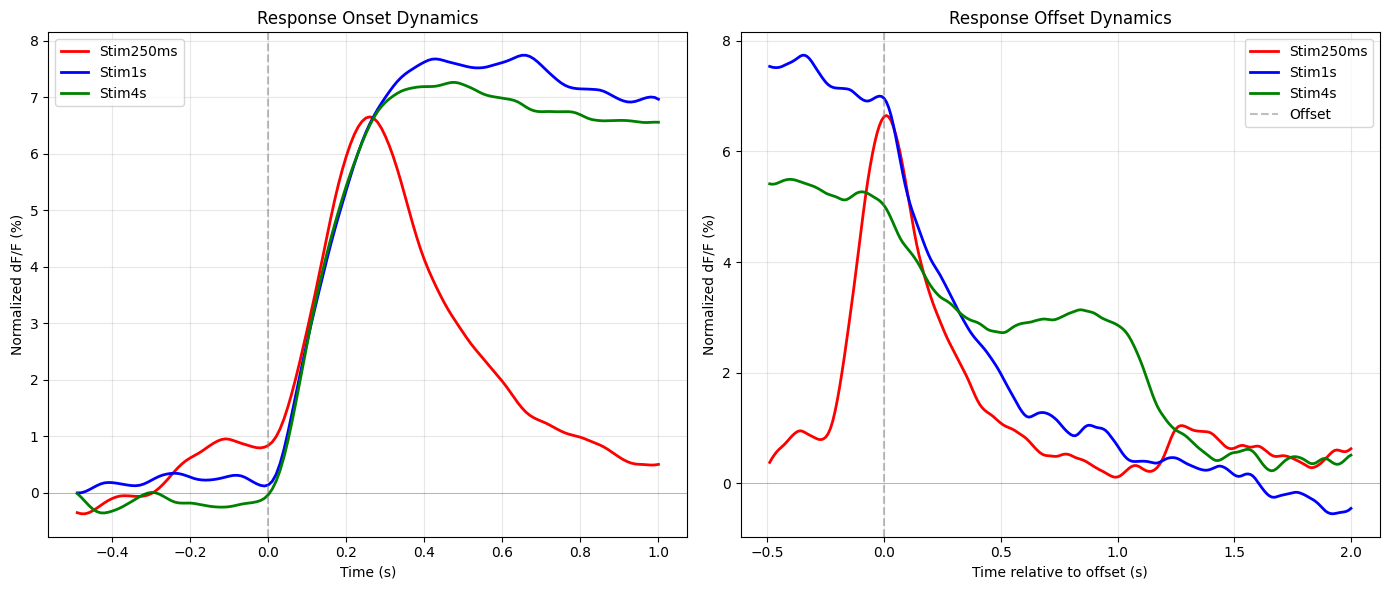

In [ ]:
print("\n" + "=" * 100)
print("RESPONSE DYNAMICS COMPARISON")
print("=" * 100)
print("\nComparing response dynamics across stimulus conditions.\n")

# Plot comparison of response dynamics
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Onset dynamics (first 1s)
ax = axes[0]
for condition_label, data_dict in organized_data.items():
    time_vec = data_dict["time_vector"]
    normalized_trials = data_dict["normalized"]

    # Focus on -0.5 to 1s
    mask = (time_vec >= -0.5) & (time_vec <= 1.0)
    mean_trace = np.nanmean(normalized_trials[:, mask], axis=0)

    color = colors.get(condition_label, "black")
    ax.plot(time_vec[mask], mean_trace, color=color, linewidth=2, label=condition_label)

ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
ax.axhline(0, color="black", linestyle="-", linewidth=0.5, alpha=0.3)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Normalized dF/F (%)")
ax.set_title("Response Onset Dynamics")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Offset dynamics (last 0.5s of stim + 2s post)
ax = axes[1]
for condition_label, data_dict in organized_data.items():
    time_vec = data_dict["time_vector"]
    normalized_trials = data_dict["normalized"]
    stim_duration = data_dict["duration"]

    # Focus on last part of stim and post
    mask = (time_vec >= (stim_duration - 0.5)) & (time_vec <= (stim_duration + 2.0))
    if np.any(mask):
        mean_trace = np.nanmean(normalized_trials[:, mask], axis=0)
        time_relative_to_offset = time_vec[mask] - stim_duration

        color = colors.get(condition_label, "black")
        ax.plot(time_relative_to_offset, mean_trace, color=color, linewidth=2, label=condition_label)

ax.axvline(0, color="gray", linestyle="--", alpha=0.5, label="Offset")
ax.axhline(0, color="black", linestyle="-", linewidth=0.5, alpha=0.3)
ax.set_xlabel("Time relative to offset (s)")
ax.set_ylabel("Normalized dF/F (%)")
ax.set_title("Response Offset Dynamics")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()